# Statistical Inference

Notebooks 01–02 distinguished population moments from quantities calculated from a finite sample. The repeated-sample covariance example in Notebook 02 showed that the same population can produce different estimates. This notebook asks how to assess that variation when the population parameter is unknown.

The focus is frequentist inference: first the statistical model and estimator, then bias, variance and MSE, followed by confidence intervals and hypothesis tests. Maximum likelihood provides an estimation method, and the final examples compare location inference under the distributional assumptions introduced earlier.

Gaussian, Student-t and multivariate Gaussian distributions are examples of parametric statistical models. Later notebooks introduce parametric time-series models. Notebook 04 first takes a different approach, describing the empirical distribution without choosing a parametric family.

Throughout these examples, $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ is a simplifying sampling framework. Financial returns need not be fully IID because dependence over time can matter. The time-series notebooks address that distinction.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from scipy.optimize import minimize
from scipy.integrate import quad
from finstats.inference import (bias, estimator_variance, mean_squared_error, standard_error_mean,
    mean_confidence_interval, variance_confidence_interval,
    gaussian_loglikelihood, gaussian_mle)

## 1. Statistical Models and Inferential Problems

### Statistical models

A statistical model is a family of probability distributions
$$\mathcal P=\{F(\cdot;\theta):\theta\in\Theta\},$$
where $\theta$ is the population parameter and $\Theta$ its parameter space. A parametric model uses a finite-dimensional $\theta$. For example, a Gaussian has $\theta=(\mu,\sigma^2)$ with $\sigma^2>0$, Student-t has location, positive scale and degrees of freedom, and a multivariate Gaussian has mean vector and covariance matrix.

### Random samples, estimators and estimates

A random sample $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ has an unknown, fixed generating parameter. An estimator $\hat\theta_n=T(X_1,\ldots,X_n)$ is random because it is a function of that sample. Its observed value $T(x_1,\ldots,x_n)$ is an estimate. For example, $\bar X_n$ estimates $\mu$, while $\bar x_n$ is the realized estimate.

### Inferential problems

Point estimation supplies a value, confidence intervals describe uncertainty, and hypothesis tests assess a specified claim about the parameter. Each answer depends on the assumed sampling model.

## 2. Bias, Variance and Mean-Squared Error

### Bias

The bias of an estimator is
$$\operatorname{bias}(\hat\theta_n)=E[\hat\theta_n]-\theta.$$
An estimator is unbiased when its expectation equals the population parameter. For iid observations with mean $\mu$, $E[\bar X_n]=\mu$. This statement concerns the sampling distribution, rather than equality between every realized sample mean and $\mu$.

### Variance and standard error


The sampling variance describes dispersion of an estimator:
$$\operatorname{Var}(\hat\theta)=E[(\hat\theta-E[\hat\theta])^2],\qquad
SE(\hat\theta)=\sqrt{\operatorname{Var}(\hat\theta)}.$$
For iid observations with finite variance,
$$\operatorname{Var}(\bar X)=\sigma^2/n,\qquad SE(\bar X)=\sigma/\sqrt n.$$
The observation variance $\sigma^2$ and estimator variance $\sigma^2/n$ describe different objects. The realized sample variance $s^2$ estimates the former. The quantity $s/\sqrt n$ estimates the mean estimator's standard error.

### Mean-squared error

Mean-squared error measures squared estimation error averaged over random samples:
$$\operatorname{MSE}(\hat\theta_n)=E[(\hat\theta_n-\theta)^2]
=\operatorname{Var}(\hat\theta_n)+\operatorname{bias}(\hat\theta_n)^2.$$
To obtain the decomposition, write the error as $(\hat\theta_n-E[\hat\theta_n])+(E[\hat\theta_n]-\theta)$. The cross term has expectation zero.

MSE combines dispersion and bias, so a smaller variance can compensate for some bias. Zero MSE requires both zero variance and zero bias. Unbiasedness alone does not imply zero MSE. For the sample mean, $\operatorname{MSE}(\bar X_n)=\sigma^2/n$.

### A variance-estimation example

The two empirical variances introduced in Notebook 01 give a direct comparison. Under IID $N(\mu,\sigma^2)$ sampling, write $M_2=n^{-1}\sum_i(X_i-\bar X)^2$ and $S^2=nM_2/(n-1)$. Then
$$\operatorname{bias}(M_2)=-\frac{\sigma^2}{n},\qquad \operatorname{bias}(S^2)=0,$$
$$\operatorname{Var}(M_2)=\frac{2(n-1)\sigma^4}{n^2},\qquad
\operatorname{Var}(S^2)=\frac{2\sigma^4}{n-1}.$$
These follow from $(n-1)S^2/\sigma^2\sim\chi^2_{n-1}$, whose variance is $2(n-1)$. Combining bias and variance gives
$$\operatorname{MSE}(M_2)=\frac{(2n-1)\sigma^4}{n^2},\qquad
\operatorname{MSE}(S^2)=\frac{2\sigma^4}{n-1}.$$
Here the biased estimator has lower MSE. Unbiasedness alone is not the same as minimum squared-error risk.

For illustration, I use 3000 independent samples of size 10 from $N(5,4)$ with seed 303. The figure and table compare both variance estimators with the fixed population variance four.

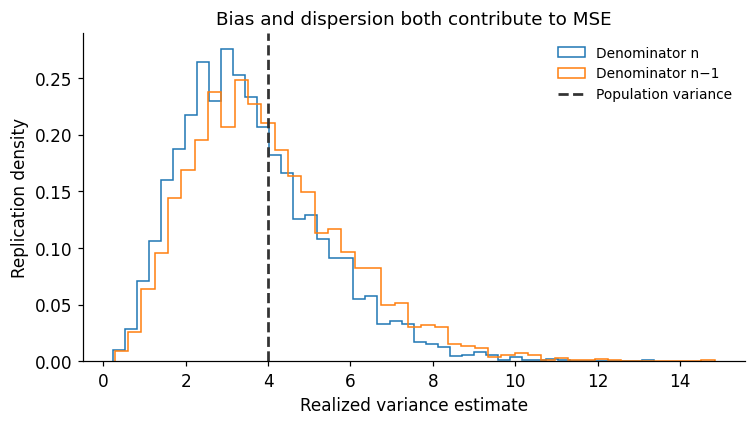

,Estimator,Bias,MC bias,Variance,MC variance,MSE,MC MSE
0,Denominator n,-0.4,-0.3917,2.8800,2.8792,3.0400,3.0327
1,Denominator n−1,0.0,0.0092,3.5556,3.5546,3.5556,3.5547


In [2]:
n, B, true_variance = 10, 3000, 4.
variance_samples = np.random.default_rng(303).normal(5, 2, size=(B, n))
variance_estimates = {"Denominator n": np.array([sample_variance(row, ddof=0) for row in variance_samples]),
                      "Denominator n−1": np.array([sample_variance(row) for row in variance_samples])}
theory = {"Denominator n": (-true_variance/n, 2*(n-1)*true_variance**2/n**2),
          "Denominator n−1": (0., 2*true_variance**2/(n-1))}
rows = []
fig, ax = plt.subplots()
for name, estimates in variance_estimates.items():
    ax.hist(estimates, bins=45, density=True, histtype="step", label=name)
    target_bias, target_variance = theory[name]
    rows.append([name, target_bias, bias(estimates, true_variance), target_variance,
                 estimator_variance(estimates, ddof=0), target_variance+target_bias**2,
                 mean_squared_error(estimates, true_variance)])
ax.axvline(true_variance, color="0.2", linestyle="--", label="Population variance")
ax.set(xlabel="Realized variance estimate", ylabel="Replication density", title="Bias and dispersion both contribute to MSE")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows, columns=["Estimator", "Bias", "MC bias", "Variance", "MC variance", "MSE", "MC MSE"]).round(4))

### Consistency

An estimator is consistent when
$$\hat\theta_n\xrightarrow{P}\theta,\qquad
\lim_{n\to\infty}P(|\hat\theta_n-\theta|\ge\varepsilon)=0\quad\text{for every }\varepsilon>0.$$
MSE consistency means $\operatorname{MSE}(\hat\theta_n)\to0$. It implies consistency in probability, but the converse need not hold. The sample mean is MSE-consistent under iid sampling with finite variance, because $\sigma^2/n\to0$. Unbiasedness and consistency describe different properties.

Both variance estimators above are consistent under Gaussian sampling, because their biases and variances tend to zero. Finite-sample bias and consistency answer different questions.

## 3. Statistical Inference — Frequentist

Bias, variance and MSE describe properties of an estimator across samples. A sampling distribution provides the probability law needed to construct intervals and tests.

### Sampling distributions

For an iid sample $X_1,\ldots,X_n$ from $N(\mu,\sigma^2)$,
$$\bar X_n\sim N(\mu,\sigma^2/n),\qquad
S_n^2=\frac1{n-1}\sum_i(X_i-\bar X_n)^2,$$
$$\frac{(n-1)S_n^2}{\sigma^2}\sim\chi^2_{n-1},\qquad
\frac{\bar X_n-\mu}{S_n/\sqrt n}\sim t_{n-1}.$$
The adjusted sample variance is unbiased and consistent. A chi-squared variable with $k$ degrees of freedom is the sum of squares of $k$ independent standard Gaussian variables. The Student-t pivot accounts for replacing the unknown observation variance by its sample estimate.

### Confidence intervals

A confidence interval has random endpoints calculated from the sample:
$$C_n=[L_n,U_n],\qquad P_\theta(\theta\in C_n)=1-\alpha.$$
The parameter is fixed. Repeated sampling generates intervals that cover it with the stated probability. Once the sample is observed, $c_n=[l_n,u_n]$ is fixed and either contains the parameter or does not.

For Gaussian observations with known $\sigma$, the interval for $\mu$ is
$$\bar X_n\pm z_{1-\alpha/2}\frac{\sigma}{\sqrt n}.$$
With unknown variance, the exact Gaussian intervals are
$$\bar X_n\pm t_{1-\alpha/2,n-1}\frac{S_n}{\sqrt n},$$
$$\left[\frac{(n-1)S_n^2}{\chi^2_{1-\alpha/2,n-1}},
\frac{(n-1)S_n^2}{\chi^2_{\alpha/2,n-1}}\right].$$
Their calibration depends on iid Gaussian sampling. For illustration, I calculate realized 95% intervals from a size-ten sample of $N(5,4)$ with seed 314. I later use the same sample for the likelihood, so the uncertainty and estimation calculations concern the same observations.

In [3]:
alpha = .05
likelihood_sample = np.random.default_rng(314).normal(5, 2, size=10)
mean_interval = mean_confidence_interval(likelihood_sample, alpha)
variance_interval = variance_confidence_interval(likelihood_sample, alpha)
display(pd.DataFrame([mean_interval, variance_interval], index=["Mean μ", "Variance σ²"], columns=["Lower endpoint", "Upper endpoint"]))

,Lower endpoint,Upper endpoint
Mean μ,4.408649,5.713162
Variance σ²,0.393333,2.770815


### Hypothesis testing

A null hypothesis $H_0:\theta\in\Theta_0$ is compared with an alternative $H_1:\theta\in\Theta_1$. A statistic $T_n$ and rejection region $C_\alpha$ define the test. The significance level controls Type I error:
$$P_\theta(T_n\in C_\alpha)\le\alpha,\qquad\theta\in\Theta_0.$$
Type I error means rejecting a true null, while Type II error means failing to reject a false null. A p-value is the null probability of a statistic at least as extreme as the observed one. It is not the probability that the null hypothesis is true.

For iid $N(\theta,\sigma^2)$ observations with known $\sigma$, test $H_0:\theta=\mu_0$ against $H_1:\theta\ne\mu_0$ using
$$Z=\frac{\bar X_n-\mu_0}{\sigma/\sqrt n},\qquad C_\alpha=\{|Z|>z_{1-\alpha/2}\}.$$
The two-sided p-value is $2[1-\Phi(|z_{obs}|)]$.

In the return example, $n=100$, $\sigma=.02$, $\bar x=.005$ and $\mu_0=0$. Then $z_{obs}=2.5$ and the p-value is approximately $.0124$. At the 5% level this is evidence against a zero population mean under the assumed model.

In [4]:
alpha = .05
observed_mean, known_sigma, observed_n = .005, .02, 100
observed_se = standard_error_mean(known_sigma, observed_n)
z_observed = observed_mean/observed_se
p_value = 2*stats.norm.sf(abs(z_observed))
z_critical = stats.norm.ppf(1-alpha/2)
print(f"z={z_observed:.3f}, p-value={p_value:.4f}")
print("95% known-variance mean interval:",
      np.round([observed_mean-z_critical*observed_se, observed_mean+z_critical*observed_se], 6))

z=2.500, p-value=0.0124
95% known-variance mean interval: [0.00108 0.00892]


## 4. Maximum Likelihood Estimation

The preceding intervals and tests used Gaussian sampling results. Likelihood provides a common estimation framework for Gaussian and other parametric models. Estimation and the calibration of inferential uncertainty remain separate steps.

### Likelihood and log-likelihood

Let $Y_1,\ldots,Y_n$ be iid with density or mass function $f(y;\theta)$. For observed values $y_1,\ldots,y_n$, the likelihood is the joint density or mass viewed as a function of $\theta$:
$$L(\theta;y)=\prod_{i=1}^n f(y_i;\theta),\qquad
\ell(\theta;y)=\sum_{i=1}^n\log f(y_i;\theta).$$
The sample is fixed when comparing parameter values. A likelihood is not a probability distribution over parameters. Its logarithm preserves the maximizing parameter.

### Maximizing the likelihood

The estimate maximizes likelihood for the observed sample:
$$\hat\theta_{ML}(y)=\operatorname*{arg\,max}_{\theta\in\Theta}L(\theta;y)
=\operatorname*{arg\,max}_{\theta\in\Theta}\ell(\theta;y).$$
Before observing the sample, $\hat\theta_{ML}(Y)$ is an estimator and therefore a random variable.

### Analytical Gaussian benchmark

For $\theta=(\mu,v)$ with $v=\sigma^2>0$,
$$\ell(\mu,v)=-\frac n2\log(2\pi v)-\frac1{2v}\sum_i(x_i-\mu)^2.$$
Solving $\partial\ell/\partial\mu=0$ and $\partial\ell/\partial v=0$ gives
$$\hat\mu_{ML}=\bar x_n,\qquad \hat v_{ML}=\frac1n\sum_i(x_i-\bar x_n)^2.$$
At this solution, the Hessian is diagonal with entries $-n/\hat v_{ML}$ and $-n/(2\hat v_{ML}^2)$, both negative for a nonconstant sample. Profiling out $\mu$ confirms the global maximum. The variance MLE uses denominator $n$ and has the finite-sample bias examined above.

I retain the size-ten $N(5,4)$ sample from Section 3 for this benchmark.

In [5]:
mu_mle, variance_mle = gaussian_mle(likelihood_sample)
display(pd.DataFrame({"Population": [5., 4.], "Realized MLE": [mu_mle, variance_mle]}, index=["μ", "σ²"]))

,Population,Realized MLE
μ,5.0,5.060905
σ²,4.0,0.748228


### Numerical solutions

Student-t and skew-normal parameters generally have no joint closed-form MLE. Numerical optimization searches for a maximizer of the same log-likelihood. Starting values can affect the search, and convergence does not prove that the global maximum has been found.

For illustration, I draw 80 IID $t_5(0,1)$ observations with seed 318 and estimate location, holding scale one and degrees of freedom five fixed. This restricted example isolates the numerical step. The figure shows its log-likelihood as a function of location, and three starting values check the sensitivity of the computed estimate.

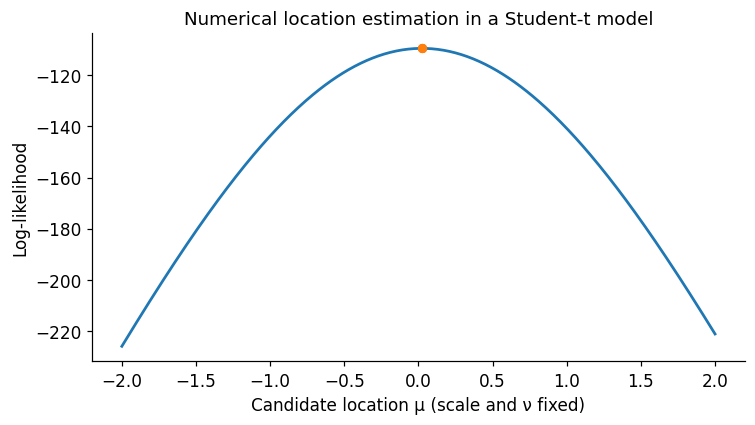

,Starting location,Estimated location,Converged,Log-likelihood
0,-2.0,0.023324,True,-109.610542
1,0.0,0.023324,True,-109.610542
2,2.0,0.023324,True,-109.610542


In [6]:
numerical_sample = np.random.default_rng(318).standard_t(5, size=80)
starts = (-2., 0., 2.)
results = [minimize(lambda p: -stats.t.logpdf(numerical_sample, 5, loc=p[0]).sum(),
                    [start], method="BFGS") for start in starts]
location_grid = np.linspace(-2, 2, 401)
loglikelihood_curve = np.array([stats.t.logpdf(numerical_sample, 5, loc=m).sum() for m in location_grid])
fig, ax = plt.subplots()
ax.plot(location_grid, loglikelihood_curve)
for result in results:
    ax.plot(result.x[0], -result.fun, "o", color="C1", markersize=5)
ax.set(xlabel="Candidate location μ (scale and ν fixed)", ylabel="Log-likelihood", title="Numerical location estimation in a Student-t model")
fig.tight_layout()
plt.show()
display(pd.DataFrame({"Starting location": starts, "Estimated location": [r.x[0] for r in results],
                      "Converged": [r.success for r in results], "Log-likelihood": [-r.fun for r in results]}))

### Fisher information and asymptotic inference

MLE itself does not require asymptotic theory. For general parametric models, its standard errors, confidence intervals and tests often rely on large-sample approximations.

The score is $s_n(\theta)=\partial\ell(\theta)/\partial\theta$. Under regularity conditions, the expected Fisher information is
$$I_n(\theta)=-E_\theta\left[\frac{\partial^2\ell(\theta)}{\partial\theta\,\partial\theta^\top}\right]=nI_1(\theta),$$
and
$$\sqrt n(\hat\theta_{ML}-\theta)\xrightarrow{d}N(0,I_1(\theta)^{-1}).$$
Thus the unscaled estimator has approximate covariance $I_n(\theta)^{-1}=I_1(\theta)^{-1}/n$. Expected information or observed negative curvature at the estimate can supply estimated standard errors. These statements require an identifiable model, an interior parameter and suitable smoothness and moment conditions.

For a scalar parameter, the approximate Wald interval is $\hat\theta\pm z_{1-\alpha/2}\widehat{SE}(\hat\theta)$. The standardized difference from a null parameter is approximately standard Gaussian. This calibration is asymptotic, unlike the exact Gaussian pivots in Section 3.

## 5. Examples of Statistical Inference

### Parameters and estimation

The inferential problem depends on the assumed model. The Gaussian mean and variance have analytical MLEs. For Laplace, location is a sample median and the scale MLE is
$$\hat\lambda_{ML}=\frac1n\sum_i|x_i-\hat\mu_{ML}|.$$
Student-t location, scale and degrees of freedom generally require numerical estimation, as do skew-normal location, scale and shape. In $SN(\mu,\lambda,\alpha)$, $\mu$ is a location parameter, not the mean when $\alpha\ne0$.

For a selective comparison, I estimate **location** with true value zero. Gaussian observations have standard deviation one. The Student-t has known scale one and $\nu=5$, Laplace has known scale one, and skew-normal has known scale one and $\alpha=3$. These nuisance parameters are held fixed to isolate location uncertainty. Only the second Gaussian case also estimates its unknown variance. The models do not have equal population variances, so this is not a ranking of estimation methods on the same DGP.

| Model | Location estimate | Interval calibration |
| --- | --- | --- |
| Gaussian, known variance | Sample mean | Exact Gaussian |
| Gaussian, unknown variance | Sample mean | Exact Student-t |
| Student-t, known scale and degrees of freedom | Numerical MLE | Asymptotic Fisher information |
| Laplace, known scale | Sample median | Asymptotic median distribution |
| Skew-normal, known scale and shape | Numerical MLE | Asymptotic Fisher information |

### Location uncertainty across repeated samples

For known scale $\lambda$, the Student-t location information is
$$I_1(\mu)=\frac{\nu+1}{\lambda^2(\nu+3)}.$$
For Laplace, the asymptotic location standard error is $\lambda/\sqrt n$. Its likelihood has a cusp, so the usual smooth-Hessian derivation is inappropriate, although median asymptotics provide this limit.

For skew-normal, write $z=(x-\mu)/\lambda$. The location score and information are
$$s_1(\mu;x)=\frac1\lambda\left[z-\alpha\frac{\phi(\alpha z)}{\Phi(\alpha z)}\right],\qquad
I_1(\mu)=E[s_1(\mu;X)^2].$$
I calculate this one-dimensional expectation by numerical integration for the fixed shape. Holding shape and scale known is essential: inverse scalar information would understate uncertainty in a joint parameter fit.

For illustration, I generate 300 independent IID samples from each DGP at $n=40$ and $200$, with seed 320. Each sample produces a location estimate and nominal 95% interval. The table reports Monte Carlo bias, dispersion, mean estimated standard error and coverage. The two Gaussian procedures share their samples and estimates, but use different intervals. The figure compares the location estimates at both sizes.

Skew-normal location information: 3.028131 (quadrature error 4.1e-09)


,n,Model,MC bias,Replication SD,Mean SE,95% coverage
0,40,"Gaussian, known σ²",0.0031,0.1531,0.1581,0.9567
1,40,"Gaussian, unknown σ²",0.0031,0.1531,0.1576,0.9533
2,40,Student-t₅,-0.0098,0.1810,0.1826,0.9533
3,40,Laplace,-0.0097,0.1850,0.1581,0.9100
4,40,Skew-normal₃,-0.0020,0.0933,0.0909,0.9533
5,200,"Gaussian, known σ²",0.0071,0.0700,0.0707,0.9600
6,200,"Gaussian, unknown σ²",0.0071,0.0700,0.0710,0.9567
7,200,Student-t₅,0.0014,0.0825,0.0816,0.9300
8,200,Laplace,0.0035,0.0755,0.0707,0.9333
9,200,Skew-normal₃,-0.0031,0.0417,0.0406,0.9200


At 95% coverage, Monte Carlo SE is about 0.0126 for B=300.


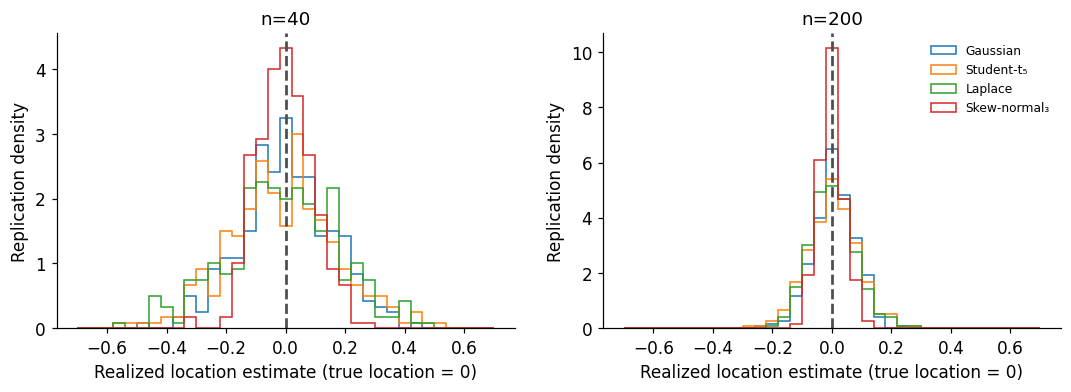

In [7]:
shape = 3.
def skew_information_integrand(z):
    ratio = np.exp(stats.norm.logpdf(shape*z)-stats.norm.logcdf(shape*z))
    score = z-shape*ratio
    return score**2 * stats.skewnorm.pdf(z, shape)
# The omitted Gaussian tails beyond ±12 have negligible contribution here.
skew_information, integration_error = quad(skew_information_integrand, -12, 12, epsabs=1e-10)
print(f"Skew-normal location information: {skew_information:.6f} (quadrature error {integration_error:.1e})")

rng_inference = np.random.default_rng(320)
B, sizes = 300, (40, 200)
z95 = stats.norm.ppf(.975)
families = {"Gaussian": stats.norm(), "Student-t₅": stats.t(5),
            "Laplace": stats.laplace(), "Skew-normal₃": stats.skewnorm(shape)}
inference_rows, inference_draws = [], {}
for n in sizes:
    for name, distribution in families.items():
        draws = distribution.rvs(size=(B, n), random_state=rng_inference)
        if name == "Gaussian":
            estimates = np.array([sample_mean(row) for row in draws])
            known_se = standard_error_mean(1., n)
            known_cover = np.abs(estimates) <= z95*known_se
            unknown_se = np.array([sample_standard_deviation(row)/np.sqrt(n) for row in draws])
            intervals = np.array([mean_confidence_interval(row) for row in draws])
            unknown_cover = (intervals[:, 0] <= 0) & (intervals[:, 1] >= 0)
            for label, se, covered in (("Gaussian, known σ²", np.full(B, known_se), known_cover),
                                       ("Gaussian, unknown σ²", unknown_se, unknown_cover)):
                inference_rows.append([n, label, bias(estimates, 0), estimates.std(ddof=1), se.mean(), covered.mean()])
        elif name == "Student-t₅":
            estimates = np.array([stats.t.fit(row, f0=5, fscale=1)[1] for row in draws])
            se = np.sqrt(1/(n*(6/8)))
            inference_rows.append([n, name, bias(estimates, 0), estimates.std(ddof=1), se,
                                   np.mean(np.abs(estimates) <= z95*se)])
        elif name == "Laplace":
            estimates = np.array([stats.laplace.fit(row, fscale=1)[0] for row in draws])
            se = 1/np.sqrt(n)
            inference_rows.append([n, name, bias(estimates, 0), estimates.std(ddof=1), se,
                                   np.mean(np.abs(estimates) <= z95*se)])
        else:
            estimates = np.array([stats.skewnorm.fit(row, f0=shape, fscale=1)[1] for row in draws])
            se = np.sqrt(1/(n*skew_information))
            inference_rows.append([n, name, bias(estimates, 0), estimates.std(ddof=1), se,
                                   np.mean(np.abs(estimates) <= z95*se)])
        inference_draws[n, name] = estimates
inference_summary = pd.DataFrame(inference_rows, columns=["n", "Model", "MC bias", "Replication SD", "Mean SE", "95% coverage"])
display(inference_summary.round(4))
print(f"At 95% coverage, Monte Carlo SE is about {np.sqrt(.95*.05/B):.4f} for B={B}.")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharex=True)
for ax, n in zip(axes, sizes):
    for name in families:
        ax.hist(inference_draws[n, name], bins=np.linspace(-.7, .7, 36), density=True, histtype="step", label=name)
    ax.axvline(0, color="0.3", linestyle="--")
    ax.set(xlabel="Realized location estimate (true location = 0)", ylabel="Replication density", title=f"n={n}")
axes[-1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Coverage fluctuates across a finite number of replications. Here the Laplace interval covers the true location in 91% of the size-40 samples, compared with about 93% at size 200. Its asymptotic standard error understates the observed dispersion in the smaller samples. These results illustrate a finite-sample limitation, rather than guaranteed 95% coverage. Exact Gaussian intervals have their stated coverage under the assumed IID Gaussian model, while the other intervals are asymptotic approximations. Increasing sample size reduces dispersion, but does not remove the dependence of inference on the model and on which parameters are treated as known.

Notebook 04 returns to the observations themselves. Histograms, density estimates and empirical quantiles provide descriptions that can then be compared with candidate parametric models.